In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, LabelEncoder
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor, RandomForestClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.svm import SVR, SVC
from xgboost import XGBRegressor, XGBClassifier
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score, classification_report
)

pd.set_option('display.max_columns', None)

df_raw = pd.read_csv('predictive_maintenance_v3.csv')
df = df_raw.copy()

machine_types = df['machine_type'].unique()
numeric_cols = ['vibration_rms', 'temperature_motor', 'current_phase_avg',
                 'pressure_level', 'rpm', 'hours_since_maintenance',
                 'ambient_temp',]
targets = ['failure_within_24h', 'failure_type', 'estimated_repair_cost']

df.head()

,timestamp,machine_id,machine_type,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,operating_mode,hours_since_maintenance,ambient_temp,rul_hours,failure_within_24h,failure_type,estimated_repair_cost
0,01/01/2024 00:00,1,CNC,0.81,49.51,5.10,23.6,860.9,idle,273.80,13.9,61.00,0,none,0
1,01/01/2024 00:03,1,CNC,0.75,40.58,5.30,23.6,899.6,idle,273.85,10.2,60.95,0,none,0
2,01/01/2024 00:21,1,CNC,0.71,49.70,NaN,21.3,862.7,idle,274.15,13.6,60.65,0,none,0
3,01/01/2024 00:45,1,CNC,0.76,43.04,4.79,22.6,870.4,idle,274.55,13.4,60.25,0,none,0
4,01/01/2024 00:54,1,CNC,0.88,41.39,4.44,22.2,881.9,idle,274.70,10.8,60.10,0,none,0


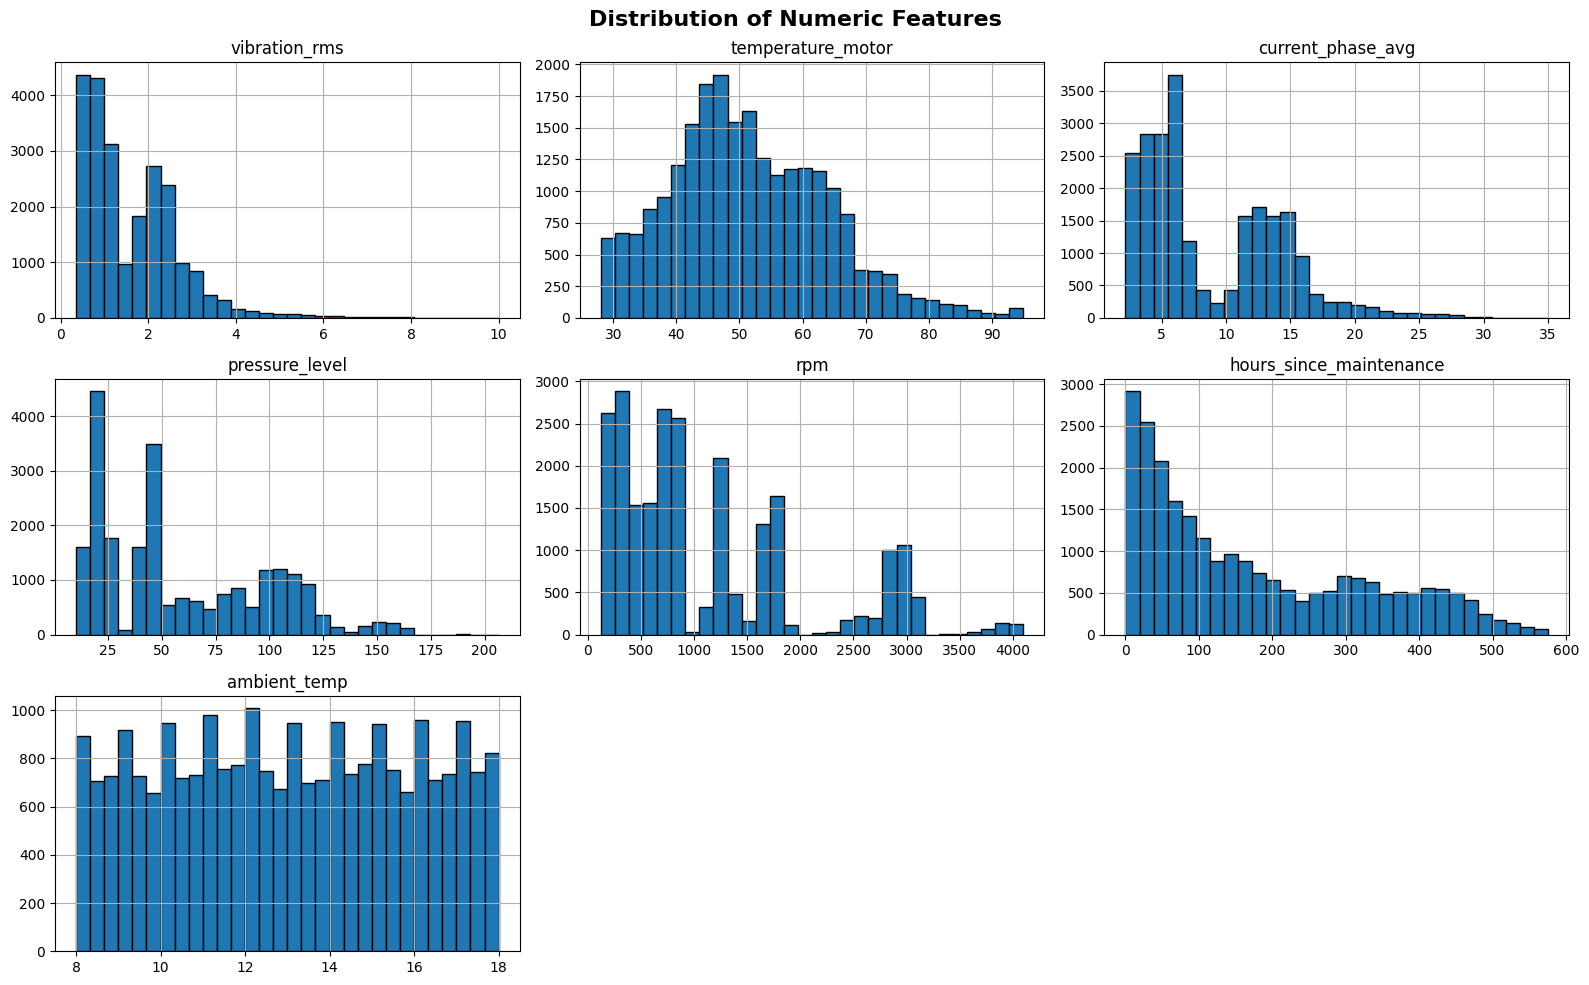

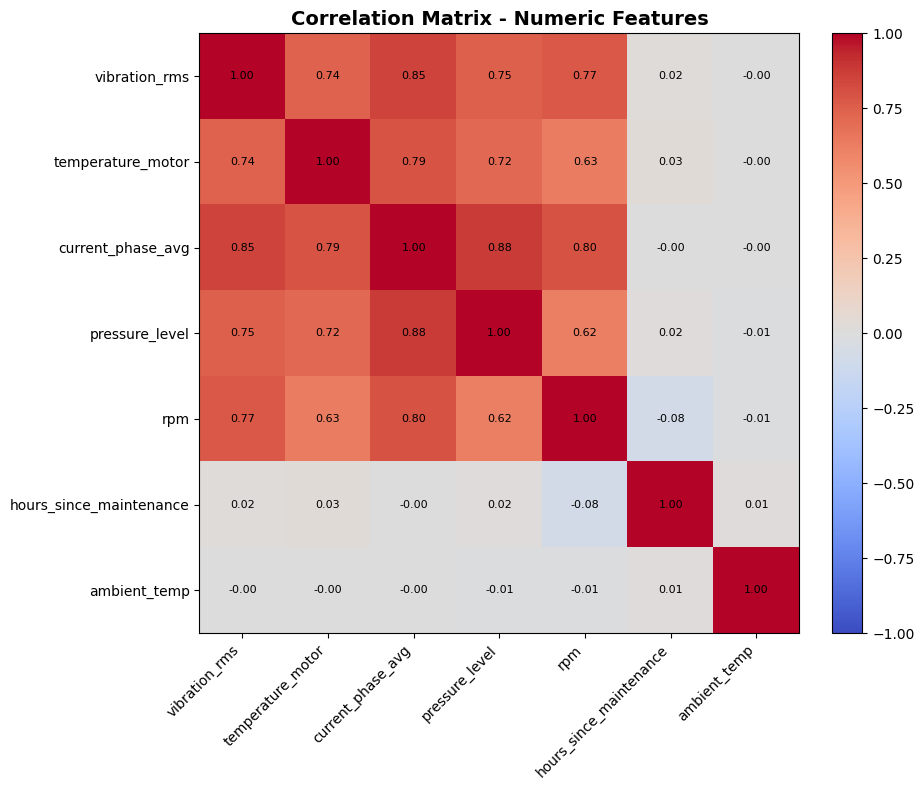

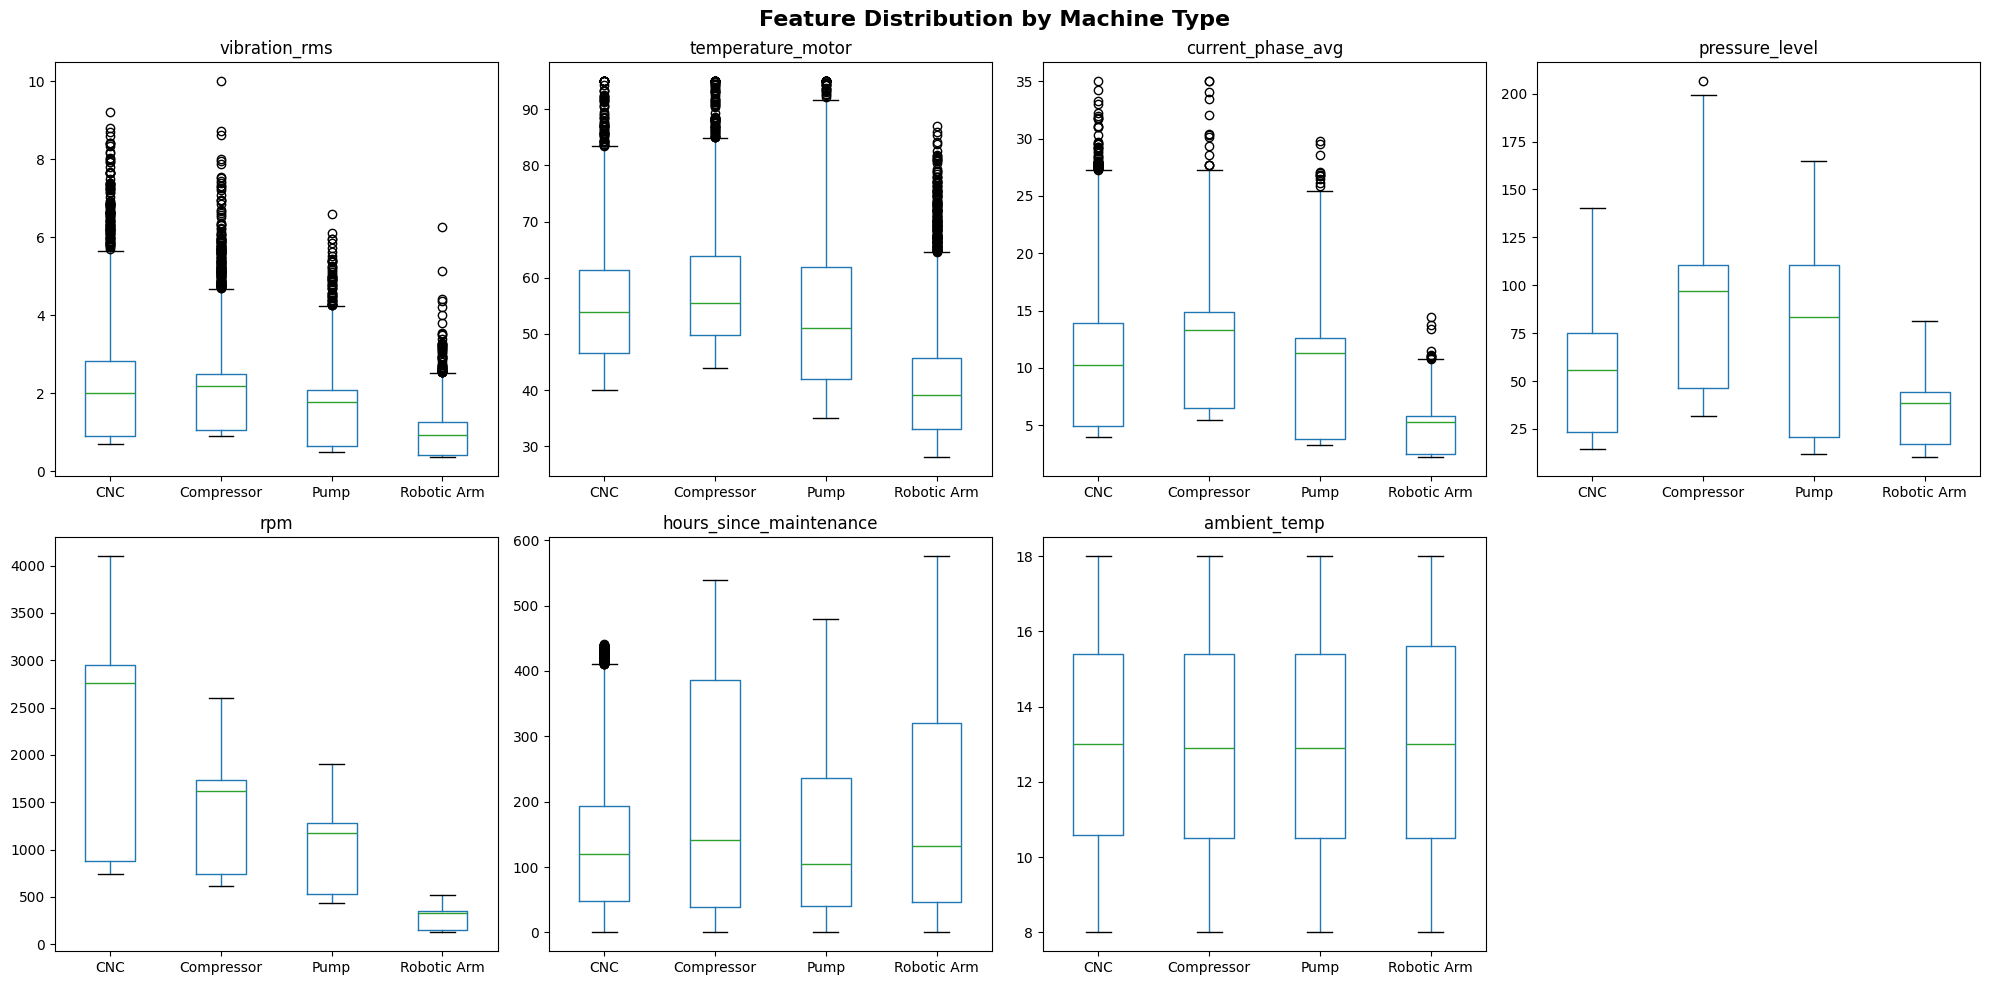

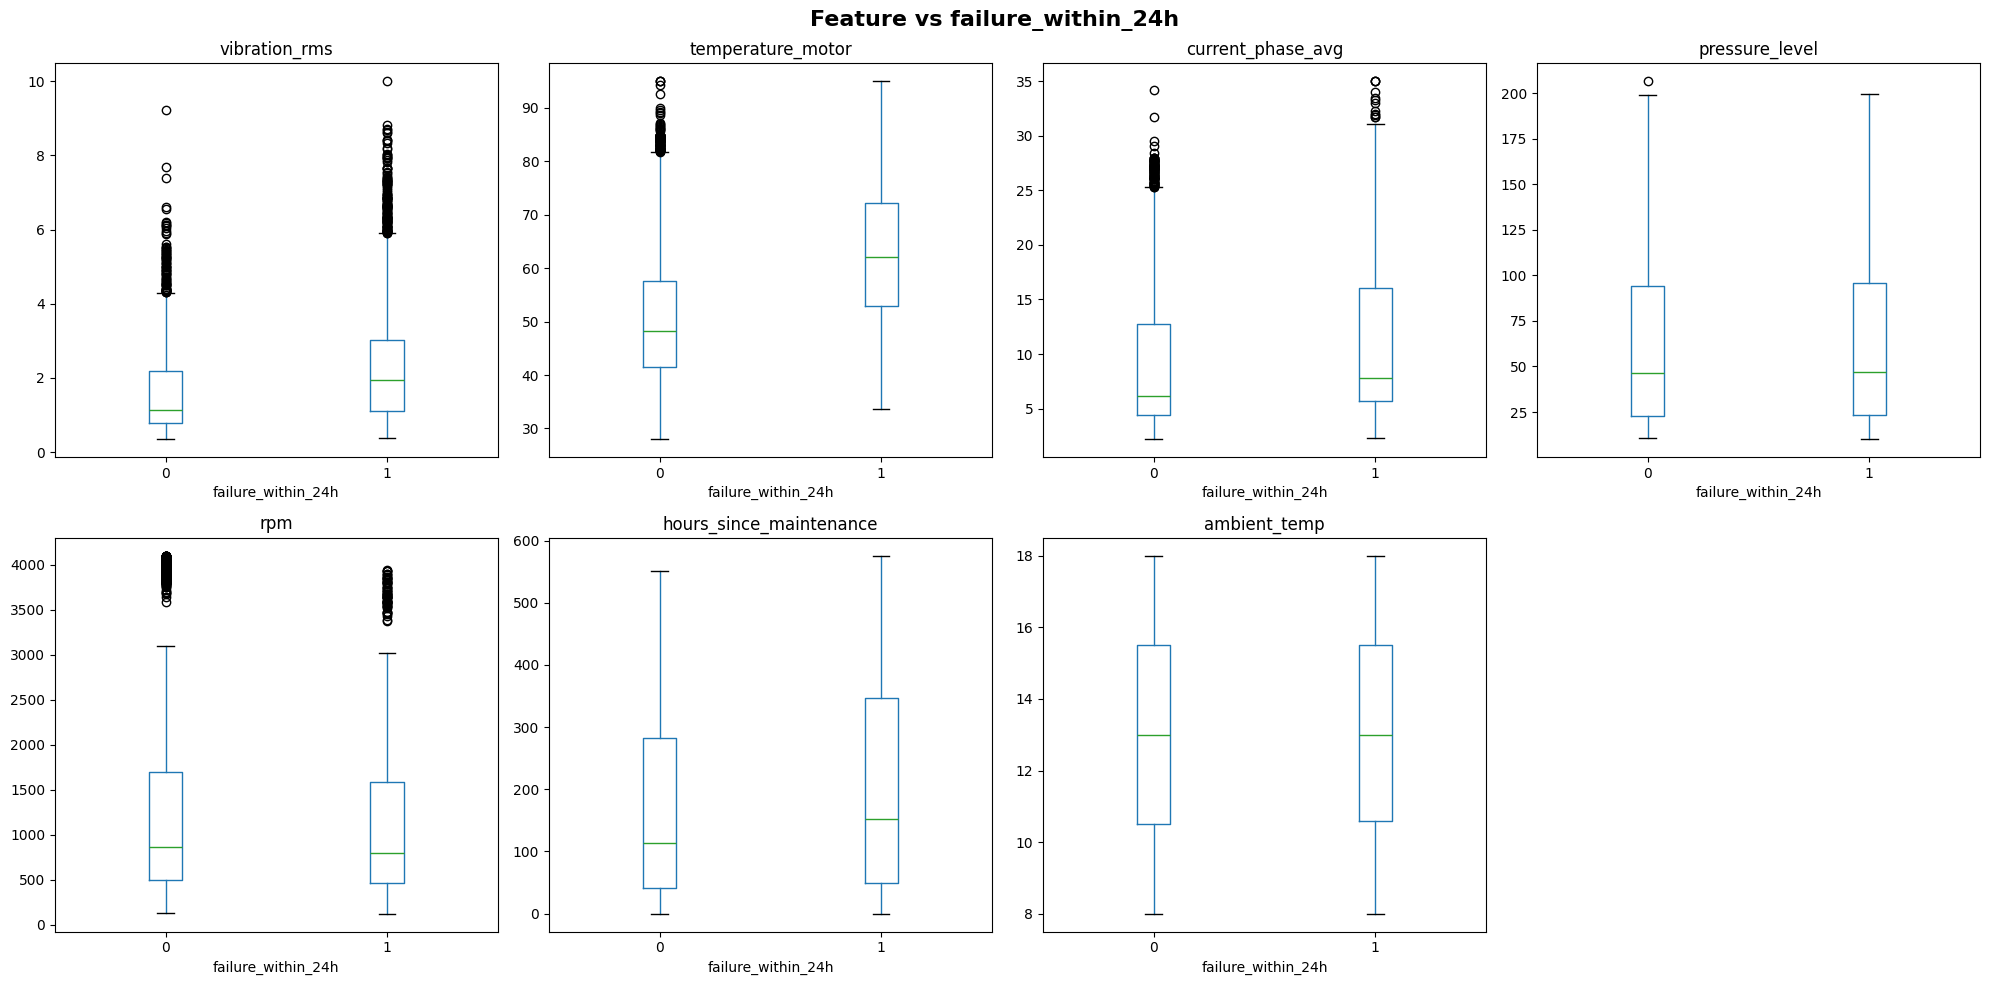

In [2]:
df[numeric_cols].hist(figsize=(16, 10), bins=30, edgecolor='black')
plt.suptitle("Distribution of Numeric Features", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
corr = df[numeric_cols].corr()
im = plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45, ha='right')
plt.yticks(range(len(numeric_cols)), numeric_cols)
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha='center', va='center',
                  color='black', fontsize=8)
plt.title("Correlation Matrix - Numeric Features", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    df.boxplot(column=col, by='machine_type', ax=axes[i], grid=False)
    axes[i].set_title(col)
    axes[i].set_xlabel('')
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])
plt.suptitle("Feature Distribution by Machine Type", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    df.boxplot(column=col, by='failure_within_24h', ax=axes[i], grid=False)
    axes[i].set_title(col)
    axes[i].set_xlabel('failure_within_24h')
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])
plt.suptitle("Feature vs failure_within_24h", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Missing Values

In [3]:
missing_cols = ['vibration_rms', 'temperature_motor',
                 'current_phase_avg', 'pressure_level', 'rpm']

print("Missing values:")
print(df[missing_cols].isnull().sum())

print("\nMissing values %:")
print((df[missing_cols].isnull().sum() / len(df) * 100).round(2))

Missing values:
vibration_rms        1000
temperature_motor     834
current_phase_avg     731
pressure_level        924
rpm                   533
dtype: int64

Missing values %:
vibration_rms        4.16
temperature_motor    3.47
current_phase_avg    3.04
pressure_level       3.84
rpm                  2.22
dtype: float64


## Fill Missing Values


In [4]:
missing_cols = ['vibration_rms', 'temperature_motor',
                 'current_phase_avg', 'pressure_level', 'rpm']

print("Missing values Before ")
print(df[missing_cols].isnull().sum())

for col in missing_cols:
    df[col] = df.groupby('machine_type')[col].transform(
        lambda x: x.fillna(x.median())
    )

print("\nMissing values After")
print(df[missing_cols].isnull().sum())

Missing values Before 
vibration_rms        1000
temperature_motor     834
current_phase_avg     731
pressure_level        924
rpm                   533
dtype: int64

Missing values After
vibration_rms        0
temperature_motor    0
current_phase_avg    0
pressure_level       0
rpm                  0
dtype: int64


## Detect Outliers

In [5]:
for m in machine_types:
    sub_df = df[df['machine_type'] == m]
    print(f"\n{'='*60}")
    print(f"Machine Type: {m}")
    print(f"{'='*60}")
    print("(breakdown by failure_within_24h)")

    for col in numeric_cols:
        Q1 = sub_df[col].quantile(0.25)
        Q3 = sub_df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outlier_rows = sub_df[(sub_df[col] < lower) | (sub_df[col] > upper)]

        if len(outlier_rows) == 0:
            continue

        print(f"\n--- Outliers in column: {col} (count: {len(outlier_rows)}) ---")
        counts = outlier_rows['failure_within_24h'].value_counts()
        counts.index.name = None
        counts.name = None
        print(counts.to_string())


Machine Type: CNC
(breakdown by failure_within_24h)

--- Outliers in column: vibration_rms (count: 115) ---
1    108
0      7

--- Outliers in column: temperature_motor (count: 78) ---
1    78

--- Outliers in column: current_phase_avg (count: 76) ---
0    39
1    37

--- Outliers in column: hours_since_maintenance (count: 108) ---
1    88
0    20

Machine Type: Pump
(breakdown by failure_within_24h)

--- Outliers in column: vibration_rms (count: 60) ---
1    46
0    14

--- Outliers in column: temperature_motor (count: 47) ---
1    42
0     5

--- Outliers in column: current_phase_avg (count: 11) ---
1    11

Machine Type: Compressor
(breakdown by failure_within_24h)

--- Outliers in column: vibration_rms (count: 158) ---
1    146
0     12

--- Outliers in column: temperature_motor (count: 96) ---
1    96

--- Outliers in column: current_phase_avg (count: 13) ---
1    13

--- Outliers in column: pressure_level (count: 1) ---
0    1

Machine Type: Robotic Arm
(breakdown by failure_wit

## Draw The BoxPlot for Outliers for each machine

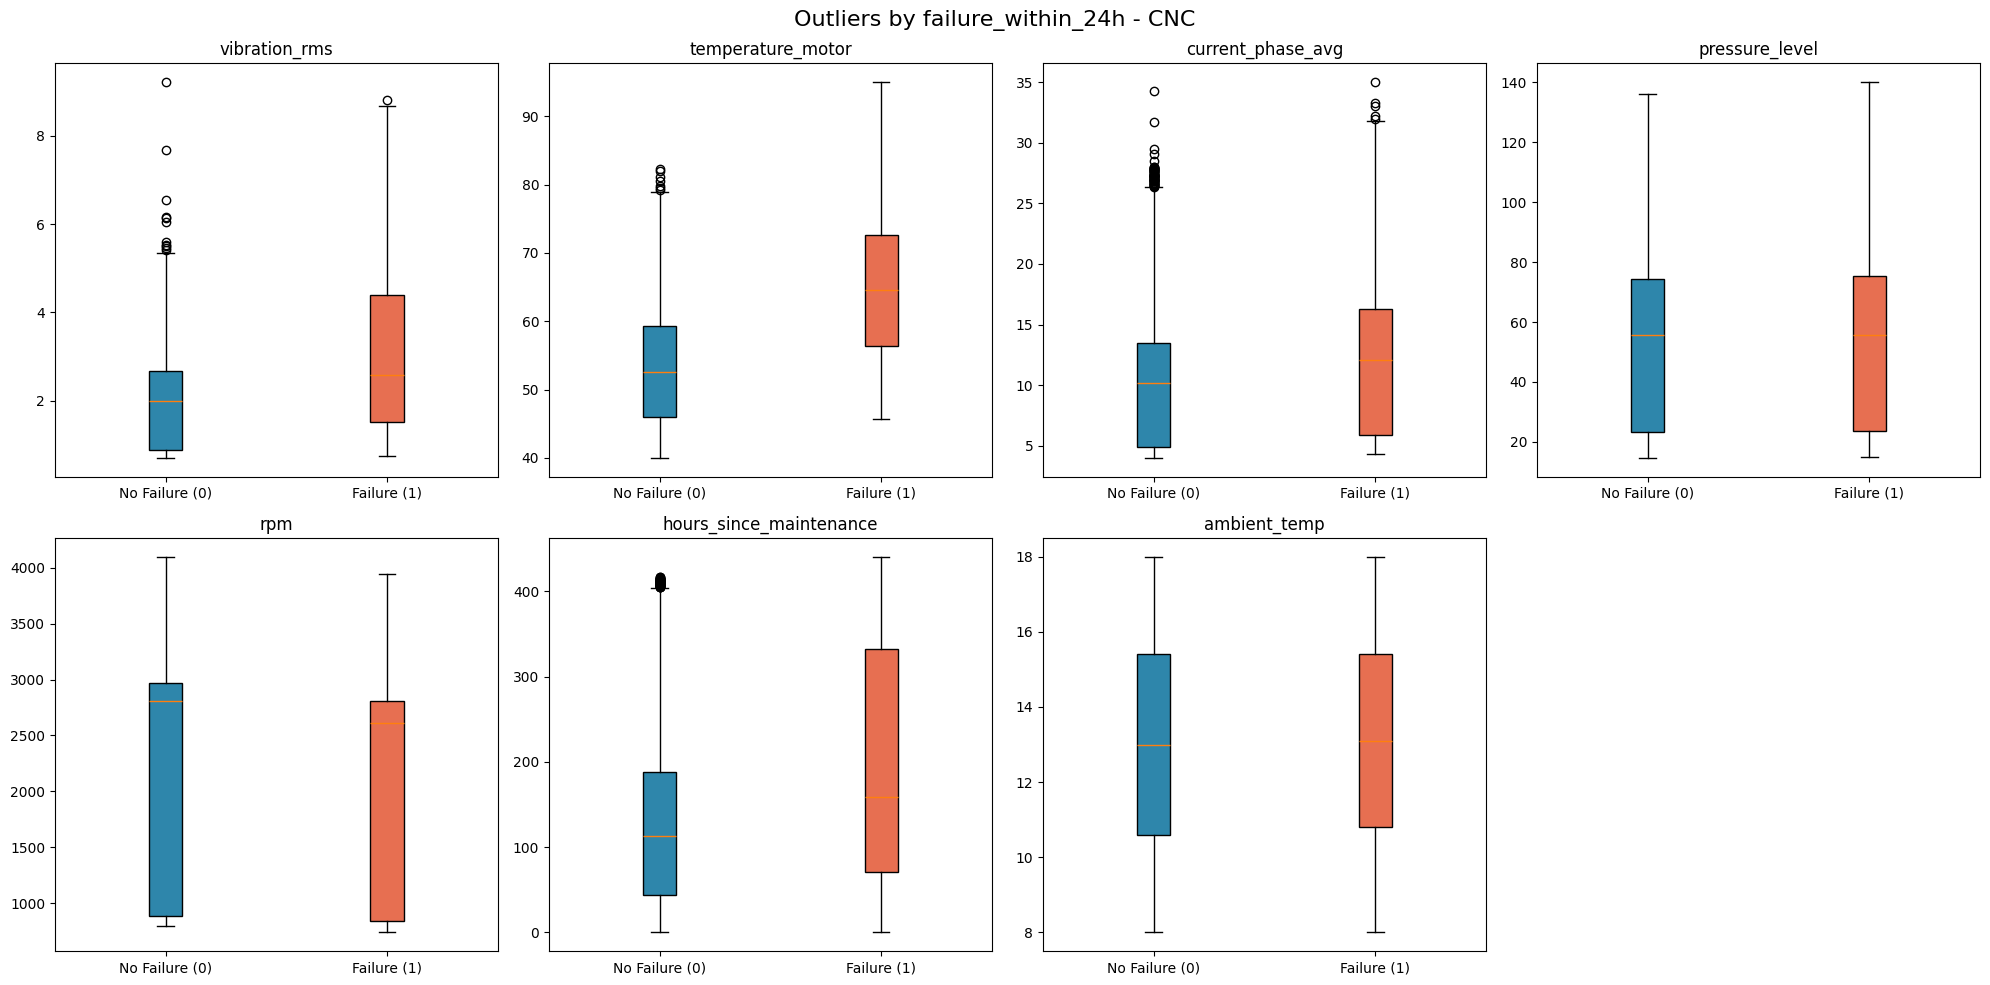

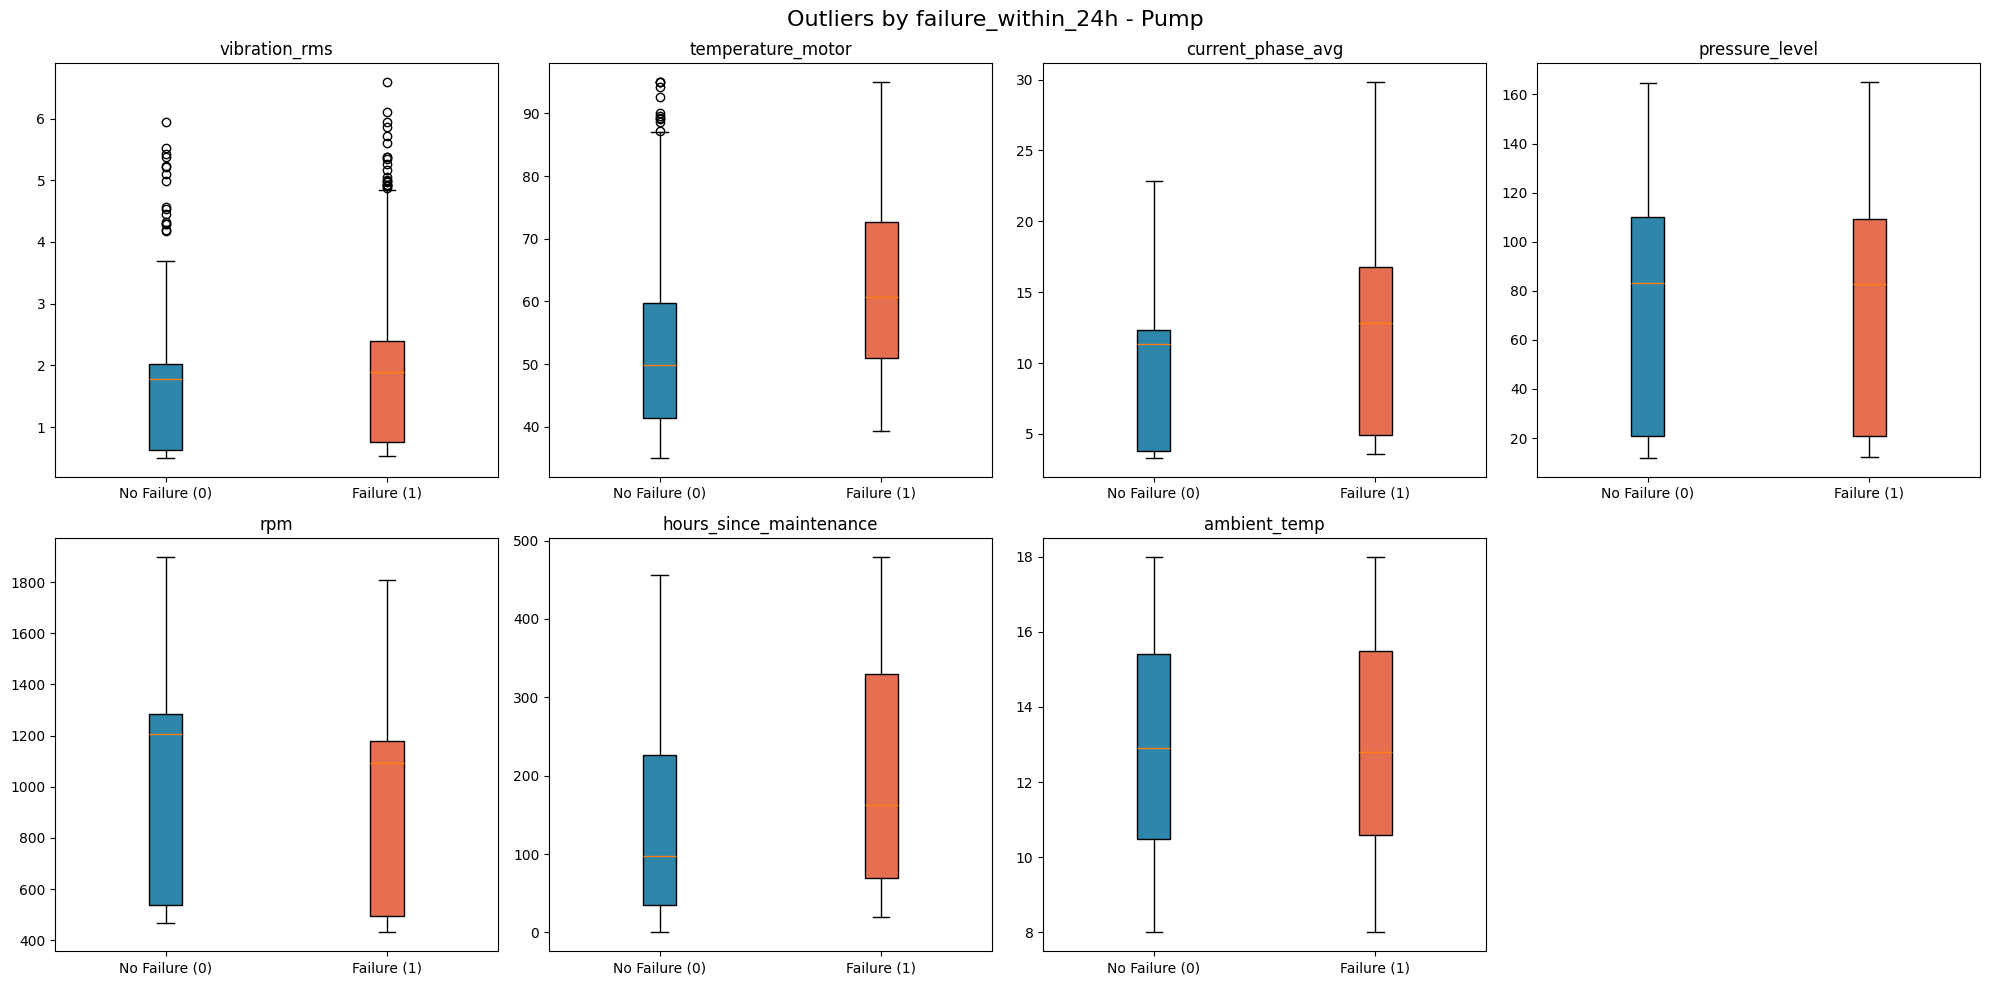

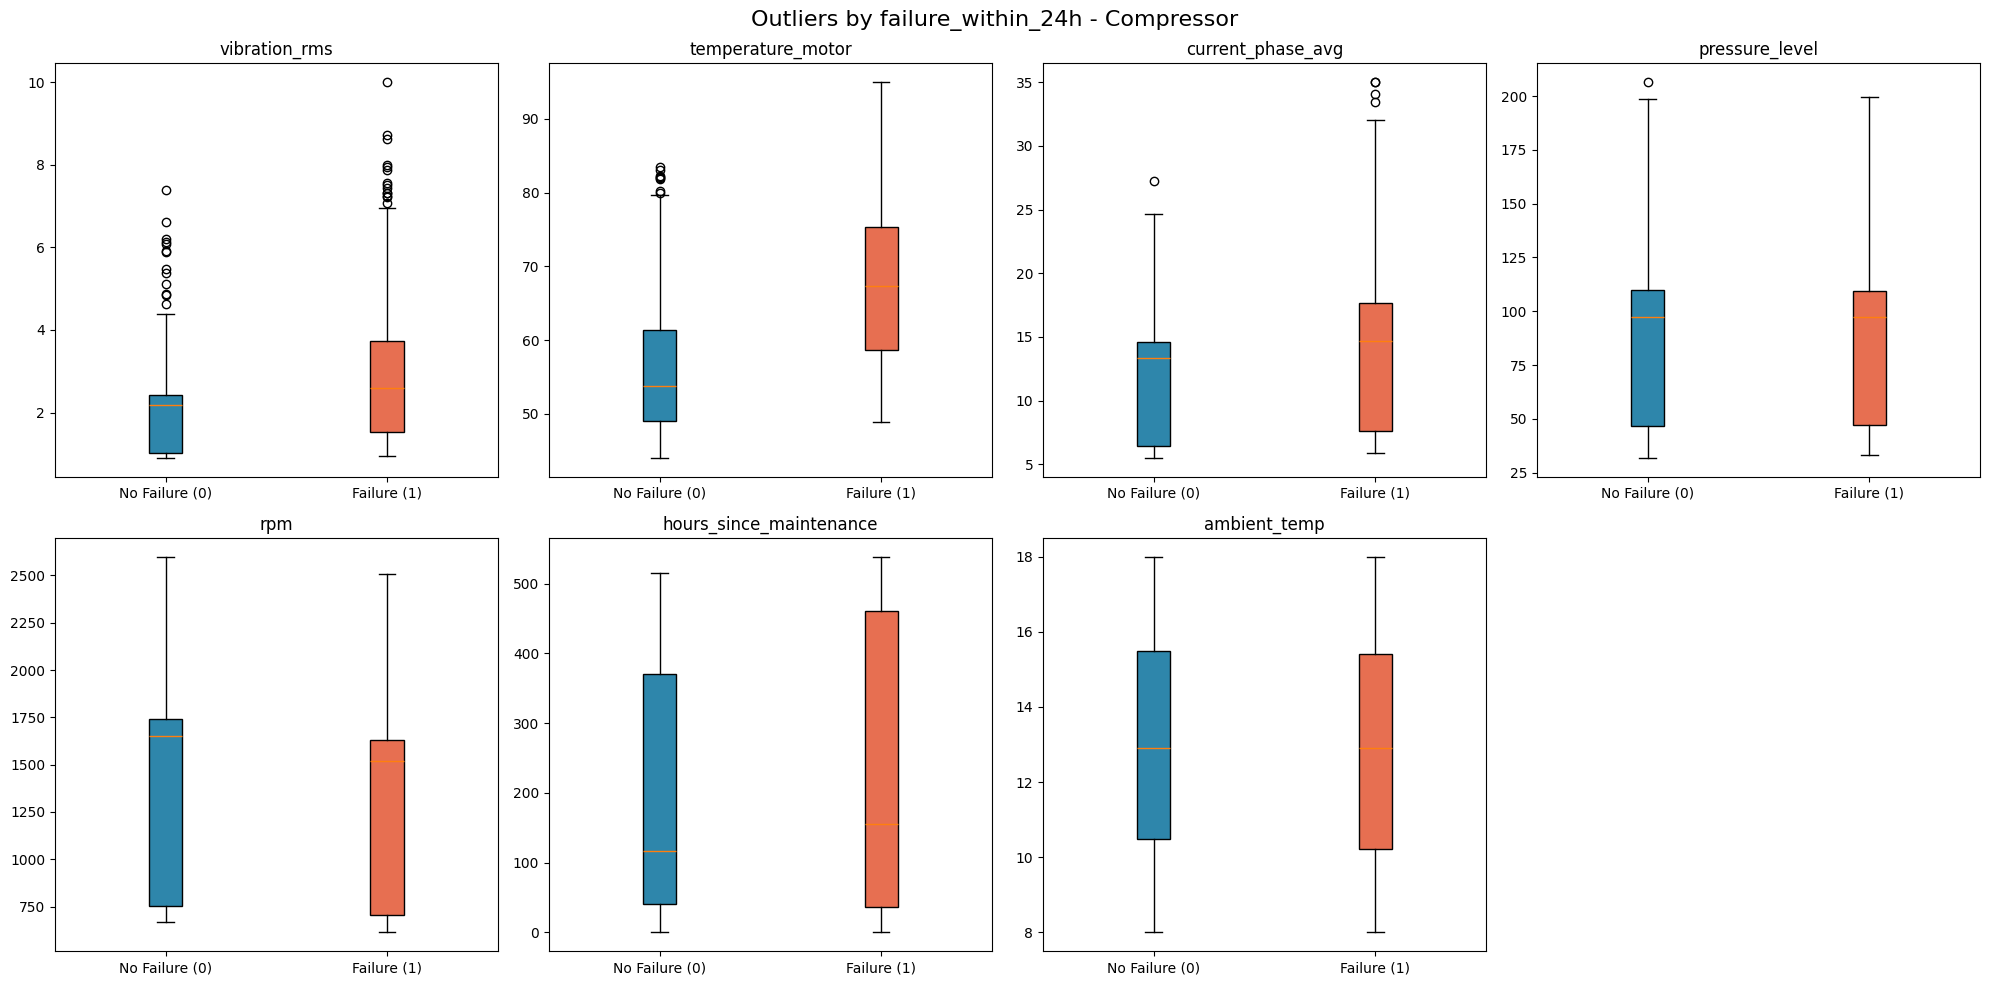

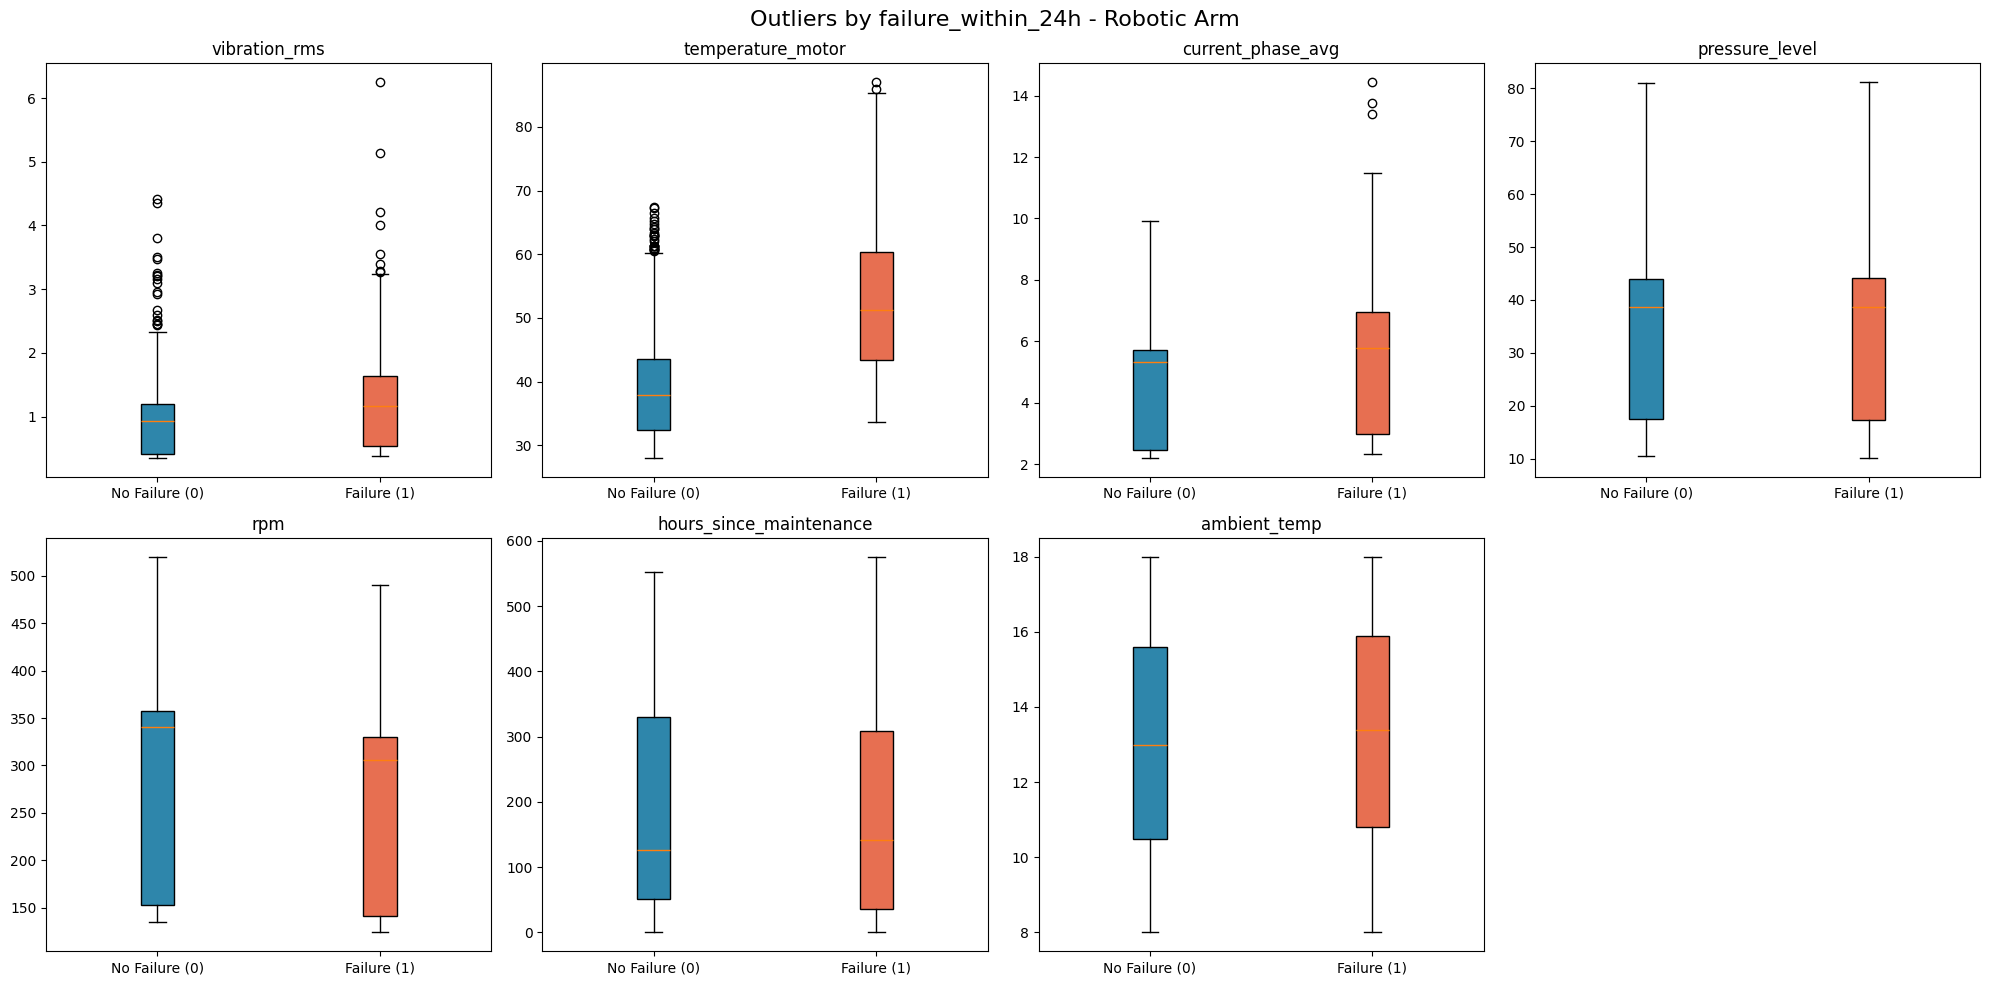

In [6]:
plot_cols = [c for c in numeric_cols if c != 'rul_hours']

for m in machine_types:
    sub_df = df[df['machine_type'] == m]

    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()

    for i, col in enumerate(plot_cols):
        data_0 = sub_df[sub_df['failure_within_24h'] == 0][col].dropna()
        data_1 = sub_df[sub_df['failure_within_24h'] == 1][col].dropna()

        bp = axes[i].boxplot([data_0, data_1], patch_artist=True)
        axes[i].set_xticklabels(['No Failure (0)', 'Failure (1)'])

        colors = ['#2E86AB', '#E76F51']
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)

        axes[i].set_title(col)

    for j in range(len(plot_cols), len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f"Outliers by failure_within_24h - {m}", fontsize=16)
    plt.tight_layout()
    plt.show()

## Drop The Outliers Rows

In [7]:
rows_to_drop = pd.Series(False, index=df.index)

for m in machine_types:
    mask_type = df['machine_type'] == m
    sub_df = df[mask_type]

    for col in numeric_cols:
        Q1 = sub_df[col].quantile(0.25)
        Q3 = sub_df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        is_outlier = (df[col] < lower) | (df[col] > upper)
        is_no_failure = (df['failure_within_24h'] == 0) & (df['failure_type'] == 'none')

        rows_to_drop |= (mask_type & is_outlier & is_no_failure)

print("Rows to be dropped:", rows_to_drop.sum())

df_before = df.shape[0]
df = df[~rows_to_drop].reset_index(drop=True)
print(f"Shape before: {df_before} -> Shape after: {df.shape[0]}")

Rows to be dropped: 121
Shape before: 24042 -> Shape after: 23921


In [8]:
for m in machine_types:
    sub_df = df[df['machine_type'] == m]
    print(f"\n===== {m} =====")
    print(f"{'Column':<25}{'No Failure (0)':<18}{'Failure (1)':<15}")
    for col in numeric_cols:
        Q1 = sub_df[col].quantile(0.25)
        Q3 = sub_df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers = sub_df[(sub_df[col] < lower) | (sub_df[col] > upper)]
        vc = outliers['failure_within_24h'].value_counts()
        print(f"{col:<25}{vc.get(0, 0):<18}{vc.get(1, 0):<15}")


===== CNC =====
Column                   No Failure (0)    Failure (1)    
vibration_rms            0                 110            
temperature_motor        0                 78             
current_phase_avg        6                 37             
pressure_level           0                 0              
rpm                      0                 0              
hours_since_maintenance  6                 88             
ambient_temp             0                 0              

===== Pump =====
Column                   No Failure (0)    Failure (1)    
vibration_rms            0                 46             
temperature_motor        0                 43             
current_phase_avg        0                 11             
pressure_level           0                 0              
rpm                      0                 0              
hours_since_maintenance  0                 0              
ambient_temp             0                 0              

===== Compressor ===

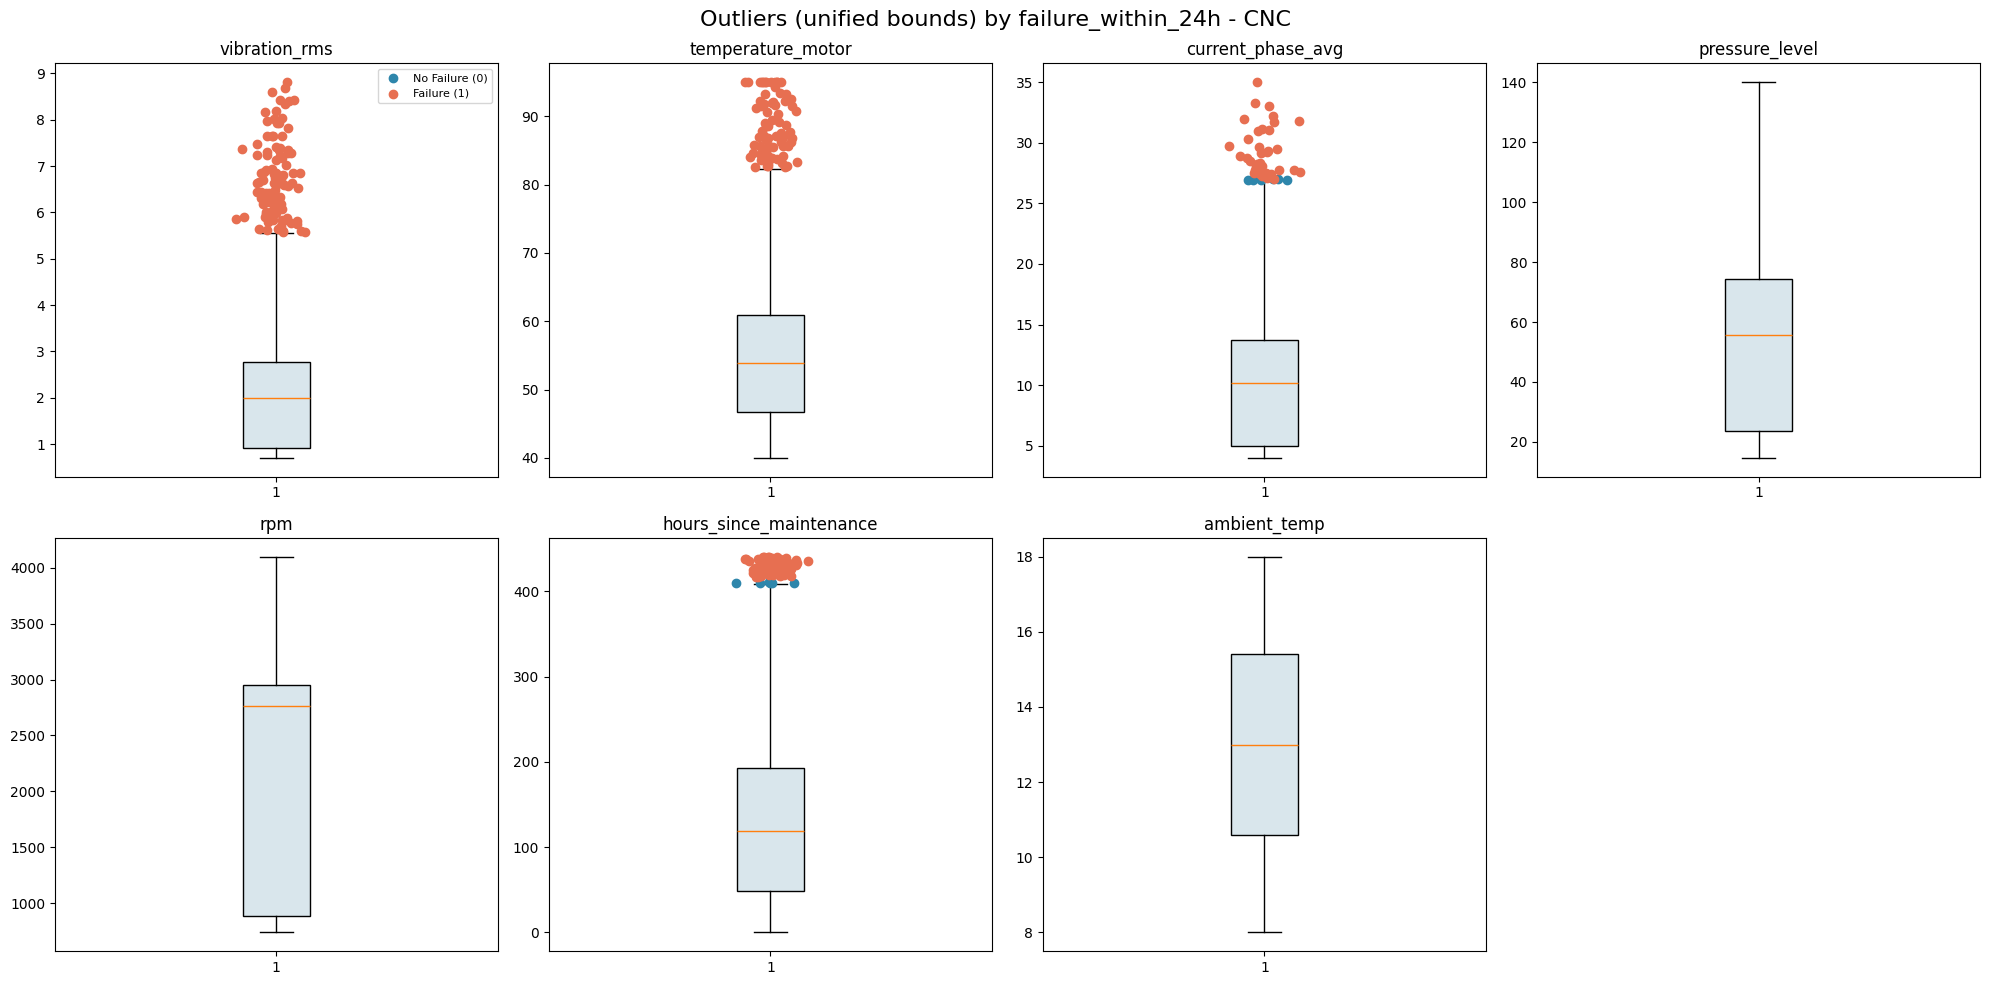

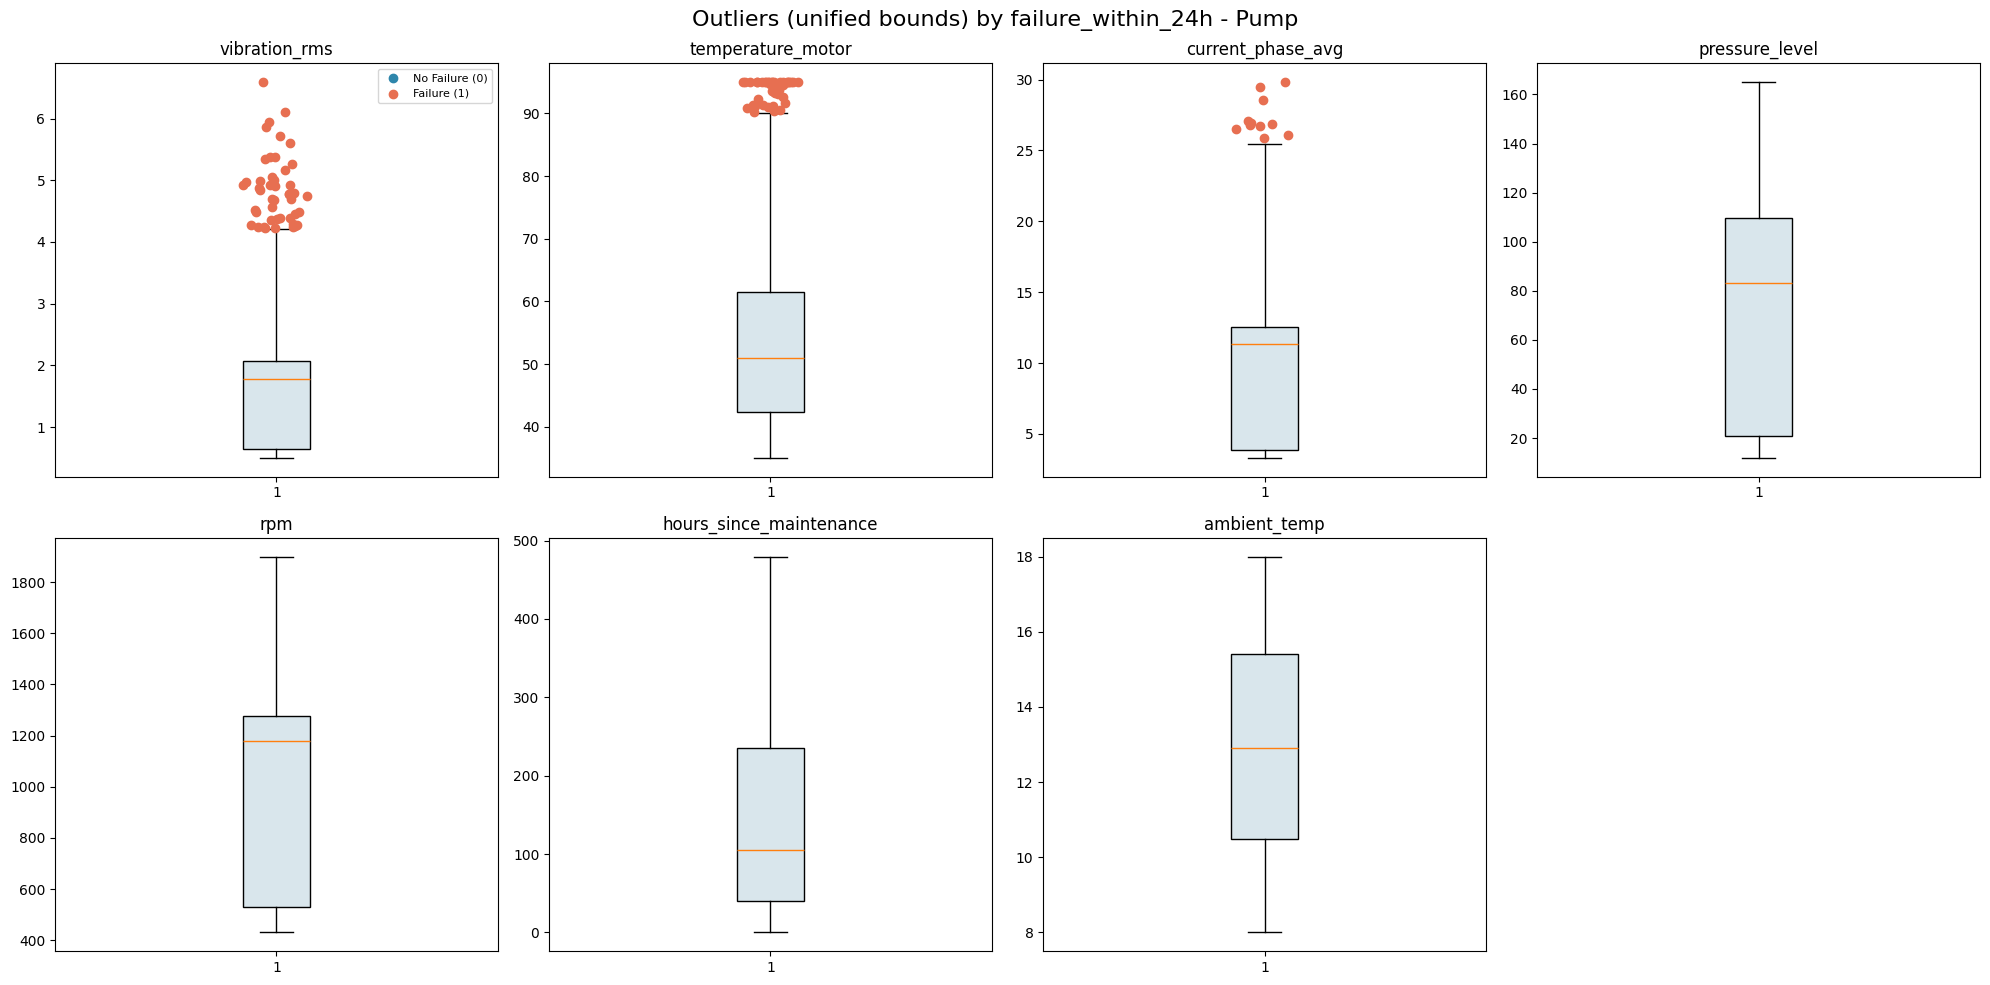

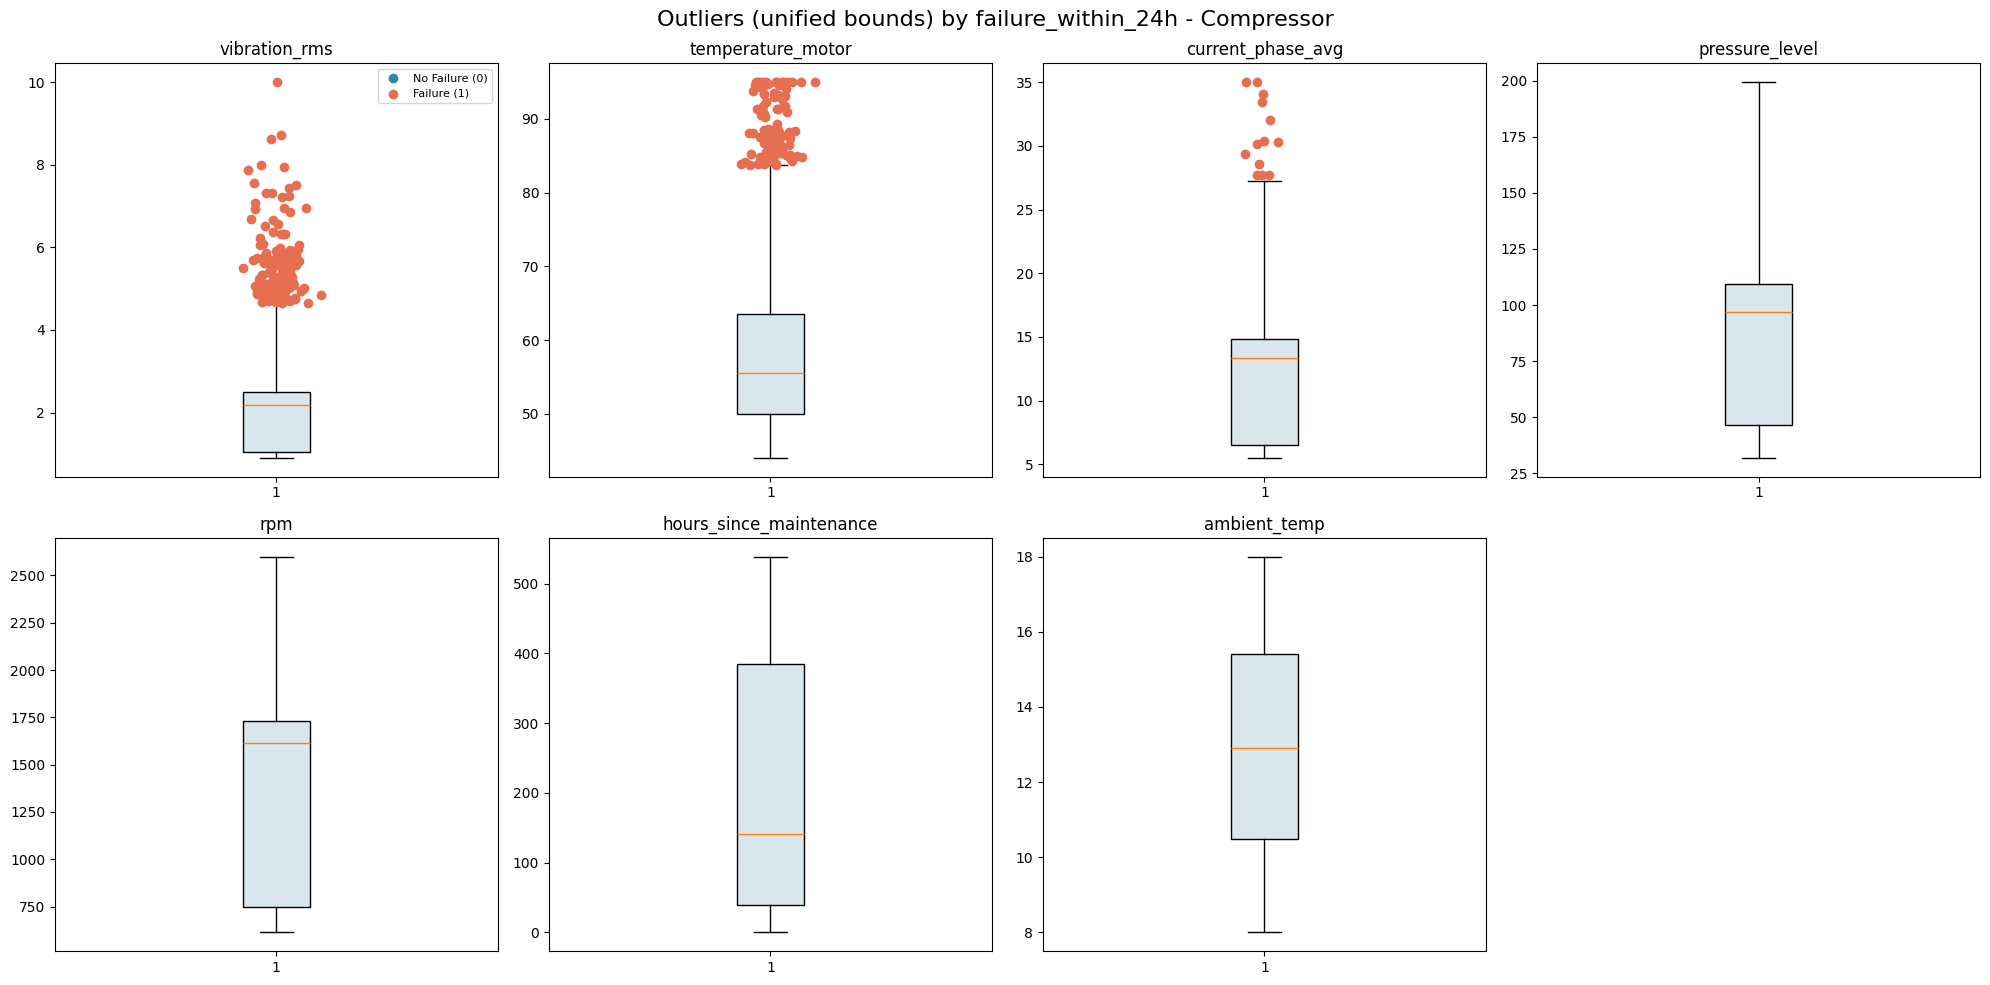

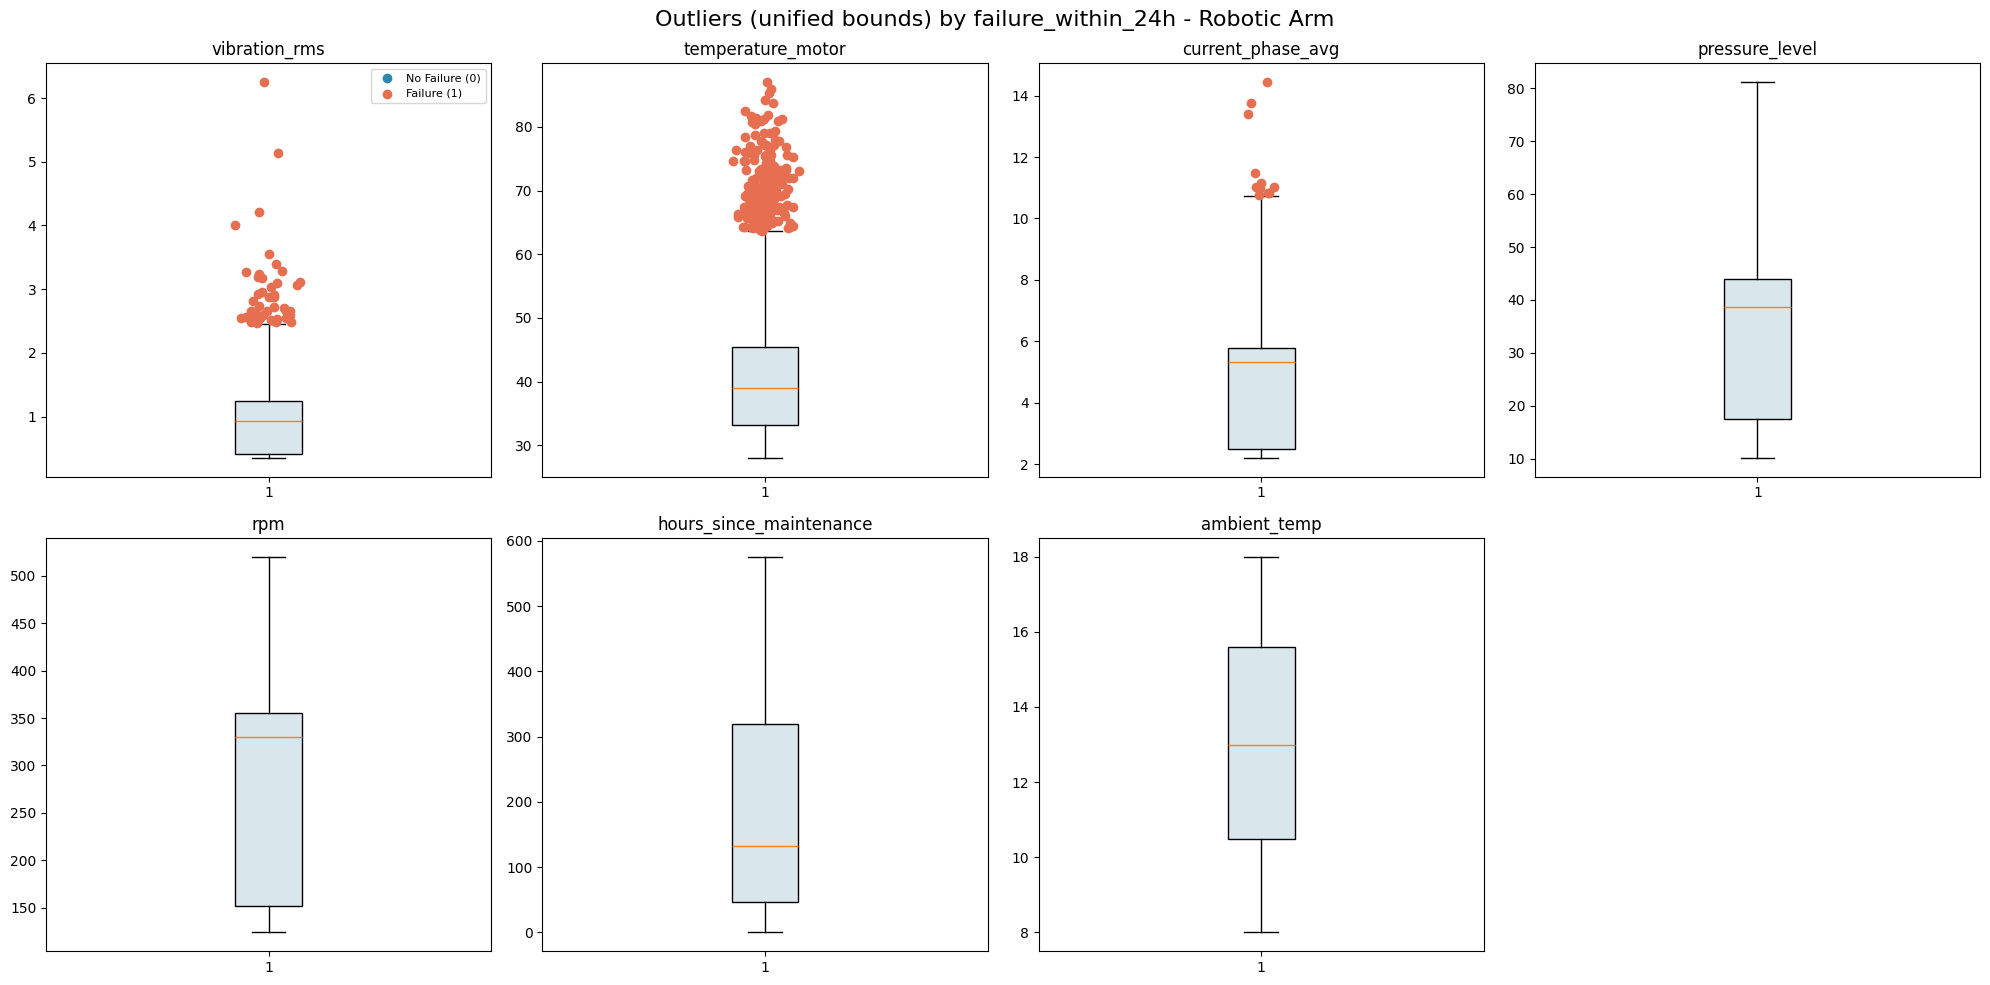

In [9]:
plot_cols = [c for c in numeric_cols if c != 'rul_hours']

for m in machine_types:
    sub_df = df[df['machine_type'] == m]

    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()

    for i, col in enumerate(plot_cols):
        data = sub_df[col].dropna()

        Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

        axes[i].boxplot(data, patch_artist=True,
                         boxprops=dict(facecolor='#D9E6EC'),
                         showfliers=False)

        outlier_rows = sub_df[(sub_df[col] < lower) | (sub_df[col] > upper)]

        x_jitter_0 = np.random.normal(1, 0.03, size=len(outlier_rows[outlier_rows['failure_within_24h'] == 0]))
        x_jitter_1 = np.random.normal(1, 0.03, size=len(outlier_rows[outlier_rows['failure_within_24h'] == 1]))

        axes[i].scatter(x_jitter_0, outlier_rows[outlier_rows['failure_within_24h'] == 0][col],
                         color='#2E86AB', label='No Failure (0)', zorder=3)
        axes[i].scatter(x_jitter_1, outlier_rows[outlier_rows['failure_within_24h'] == 1][col],
                         color='#E76F51', label='Failure (1)', zorder=3)

        axes[i].set_title(col)

    for j in range(len(plot_cols), len(axes)):
        axes[j].set_visible(False)

    axes[0].legend(loc='upper right', fontsize=8)
    fig.suptitle(f"Outliers (unified bounds) by failure_within_24h - {m}", fontsize=16)
    plt.tight_layout()
    plt.show()

## Encoding

In [10]:
targets = ['failure_within_24h', 'failure_type','estimated_repair_cost']

operating_mode_order = ['idle', 'normal', 'peak']

ordinal_encoder = OrdinalEncoder(categories=[operating_mode_order])
df['operating_mode'] = ordinal_encoder.fit_transform(df[['operating_mode']])

df = pd.get_dummies(df, columns=['machine_type'], prefix='machine_type', dtype=int)

df.head()

,timestamp,machine_id,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,operating_mode,hours_since_maintenance,ambient_temp,rul_hours,failure_within_24h,failure_type,estimated_repair_cost,machine_type_CNC,machine_type_Compressor,machine_type_Pump,machine_type_Robotic Arm
0,01/01/2024 00:00,1,0.81,49.51,5.10,23.6,860.9,0.0,273.80,13.9,61.00,0,none,0,1,0,0,0
1,01/01/2024 00:03,1,0.75,40.58,5.30,23.6,899.6,0.0,273.85,10.2,60.95,0,none,0,1,0,0,0
2,01/01/2024 00:21,1,0.71,49.70,10.22,21.3,862.7,0.0,274.15,13.6,60.65,0,none,0,1,0,0,0
3,01/01/2024 00:45,1,0.76,43.04,4.79,22.6,870.4,0.0,274.55,13.4,60.25,0,none,0,1,0,0,0
4,01/01/2024 00:54,1,0.88,41.39,4.44,22.2,881.9,0.0,274.70,10.8,60.10,0,none,0,1,0,0,0


## Train / Test Split

In [11]:
feature_cols = ['vibration_rms', 'temperature_motor', 'current_phase_avg',
                 'pressure_level', 'rpm', 'operating_mode',
                 'hours_since_maintenance', 'ambient_temp']

machine_type_cols = [c for c in df.columns if c.startswith('machine_type_')]
all_feature_cols = feature_cols + machine_type_cols

X = df[all_feature_cols]
y = df[['failure_within_24h', 'failure_type', 'estimated_repair_cost']]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y['failure_within_24h']
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (19136, 12)
X_test: (4785, 12)


In [12]:

scaler = StandardScaler()

X_train[feature_cols] = scaler.fit_transform(X_train[feature_cols])
X_test[feature_cols] = scaler.transform(X_test[feature_cols])

print("Done scaling — fit on Train only, applied to both.")

Done scaling — fit on Train only, applied to both.


## Traning of(failure_within_24h) Target

In [13]:
y_train_target = y_train['failure_within_24h']
y_test_target = y_test['failure_within_24h']

models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'SVM': SVC(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss')
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train_target)
    y_pred = model.predict(X_test)

    results[name] = {
        'Accuracy': accuracy_score(y_test_target, y_pred),
        'Precision': precision_score(y_test_target, y_pred),
        'Recall': recall_score(y_test_target, y_pred),
        'F1': f1_score(y_test_target, y_pred)
    }



In [14]:
results_df = pd.DataFrame(results).T.round(4)
results_df = results_df.sort_values('Accuracy', ascending=False)
results_df

,Accuracy,Precision,Recall,F1
XGBoost,0.9772,0.9326,0.9129,0.9226
Random Forest,0.9724,0.9277,0.8834,0.9050
SVM,0.9494,0.8852,0.7584,0.8169
Logistic Regression,0.9404,0.8739,0.7008,0.7779


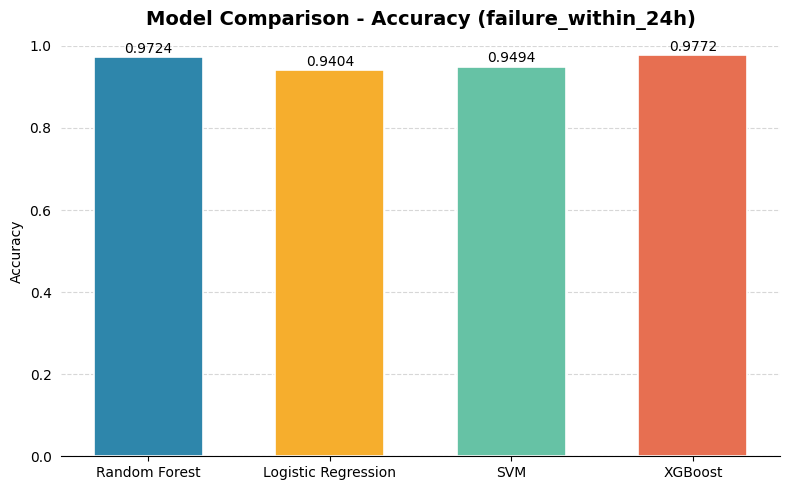

In [15]:
plt.figure(figsize=(8, 5))
model_names = list(results.keys())
accuracies = [results[m]['Accuracy'] for m in model_names]

colors = ['#2E86AB', '#F6AE2D', '#66C2A5', '#E76F51', '#9B5DE5', '#48CAE4', '#FF6B6B']

bars = plt.bar(model_names, accuracies, color=colors[:len(model_names)], edgecolor='white', linewidth=1.2, width=0.6)

ax = plt.gca()
ax.set_title('Model Comparison - Accuracy (failure_within_24h)', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.tick_params(left=False)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
              f'{acc:.4f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## failure_type Target

In [16]:

le_failure_type = LabelEncoder()

y_train_ft = y_train['failure_type']
y_test_ft = y_test['failure_type']

y_train_ft_encoded = le_failure_type.fit_transform(y_train_ft)
y_test_ft_encoded = le_failure_type.transform(y_test_ft)

print(dict(zip(le_failure_type.classes_, range(len(le_failure_type.classes_)))))

{'bearing': 0, 'electrical': 1, 'hydraulic': 2, 'motor_overheat': 3, 'none': 4}


In [17]:
models_ft = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'SVM': SVC(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='mlogloss')
}

results_ft = {}

for name, model in models_ft.items():
    if name == 'XGBoost':
        model.fit(X_train, y_train_ft_encoded)
        y_pred = model.predict(X_test)
        y_true = y_test_ft_encoded
    else:
        model.fit(X_train, y_train_ft)
        y_pred = model.predict(X_test)
        y_true = y_test_ft

    results_ft[name] = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'Recall': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'F1': f1_score(y_true, y_pred, average='macro', zero_division=0)
    }

In [18]:
results_ft_df = pd.DataFrame(results_ft).T.round(4)
results_ft_df

,Accuracy,Precision,Recall,F1
Random Forest,0.9672,0.9284,0.8416,0.8795
Logistic Regression,0.9302,0.7845,0.6200,0.6609
SVM,0.9356,0.9244,0.6199,0.6622
XGBoost,0.9789,0.9566,0.9080,0.9309


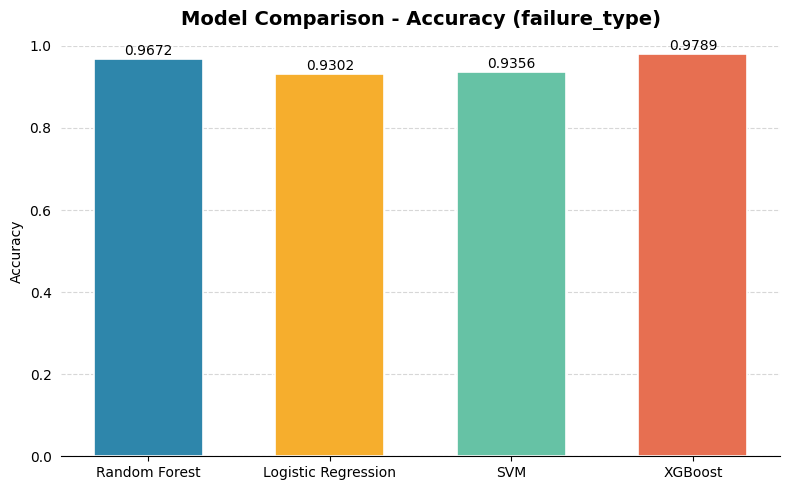

In [19]:
plt.figure(figsize=(8, 5))
model_names = list(results_ft.keys())
accuracies = [results_ft[m]['Accuracy'] for m in model_names]

colors = ['#2E86AB', '#F6AE2D', '#66C2A5', '#E76F51', '#9B5DE5', '#48CAE4', '#FF6B6B']

bars = plt.bar(model_names, accuracies, color=colors[:len(model_names)], edgecolor='white', linewidth=1.2, width=0.6)

ax = plt.gca()
ax.set_title('Model Comparison - Accuracy (failure_type)', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.tick_params(left=False)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{acc:.4f}', ha='center')

plt.tight_layout()
plt.show()

## Estimated Repair Cost

In [20]:
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_train_cost = y_train['estimated_repair_cost']
y_test_cost = y_test['estimated_repair_cost']

data_range = y_test_cost.max() - y_test_cost.min()

models_cost_final = {
    'Random Forest': RandomForestRegressor(
        n_estimators=400,
        max_depth=25,
        min_samples_split=4,
        min_samples_leaf=2,
        max_features='sqrt',
        bootstrap=True,
        random_state=42,
        n_jobs=-1
    ),

    'Bagging': BaggingRegressor(
        estimator=DecisionTreeRegressor(random_state=42),
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    'Linear Regression': LinearRegression(),

    'SVR': SVR(
        kernel='rbf',
        C=10,
        epsilon=0.1
    ),

    'XGBoost': XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
}

results_cost_final = {}

for name, model in models_cost_final.items():
    model.fit(X_train, y_train_cost)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test_cost, y_pred)
    rmse = mean_squared_error(y_test_cost, y_pred) ** 0.5
    r2 = r2_score(y_test_cost, y_pred)

    rmse_percentage = (rmse / data_range) * 100

    results_cost_final[name] = {
        'MAE': mae,
        'RMSE': rmse,
        'RMSE % of Range': rmse_percentage,
        'R2': r2
    }


In [21]:
results_cost_final_df = pd.DataFrame(results_cost_final).T.round(4)
results_cost_final_df = results_cost_final_df.sort_values('R2', ascending=False)
results_cost_final_df

,MAE,RMSE,RMSE % of Range,R2
Random Forest,284.7832,692.4268,8.6694,0.8028
XGBoost,310.9846,700.7174,8.7732,0.7980
Bagging,272.5370,708.4337,8.8698,0.7936
Linear Regression,728.0204,1065.0555,13.3349,0.5334
SVR,573.0433,1542.8292,19.3168,0.0209


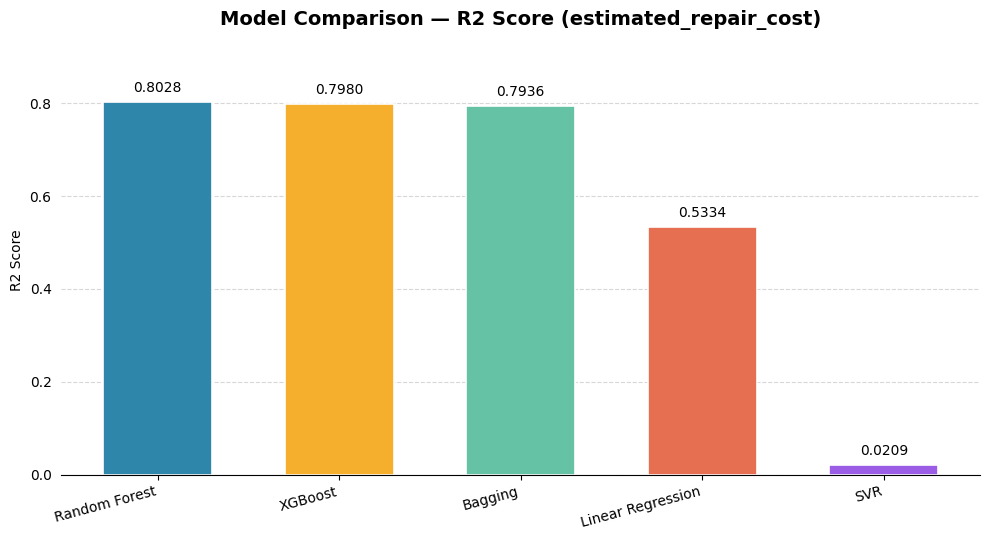

In [22]:
results_cost_final_df = pd.DataFrame(results_cost_final).T.round(4)
results_cost_final_df = results_cost_final_df.sort_values('R2', ascending=False)

model_names = results_cost_final_df.index.tolist()
r2_scores = results_cost_final_df['R2'].tolist()

colors = ['#2E86AB', '#F6AE2D', '#66C2A5', '#E76F51', '#9B5DE5', '#48CAE4', '#FF6B6B']

fig, ax = plt.subplots(figsize=(10, 5.5))
bars = ax.bar(model_names, r2_scores, color=colors[:len(model_names)], edgecolor='white', linewidth=1.2, width=0.6)

ax.set_title('Model Comparison — R2 Score (estimated_repair_cost)', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('R2 Score')
ax.set_ylim(0, max(r2_scores) * 1.15)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.tick_params(left=False)

plt.xticks(rotation=15, ha='right')

for bar, r2 in zip(bars, r2_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
             f'{r2:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

In [23]:
best_summary = []

best_model_1 = max(results, key=lambda k: results[k]['Accuracy'])
best_summary.append({
    'Target': 'failure_within_24h',
    'Best Model': best_model_1,
    'Metric': 'Accuracy',
    'Score': results[best_model_1]['Accuracy']
})

best_model_2 = max(results_ft, key=lambda k: results_ft[k]['Accuracy'])
best_summary.append({
    'Target': 'failure_type',
    'Best Model': best_model_2,
    'Metric': 'Accuracy',
    'Score': results_ft[best_model_2]['Accuracy']
})

best_model_4 = max(results_cost_final, key=lambda k: results_cost_final[k]['R2'])
best_summary.append({
    'Target': 'estimated_repair_cost',
    'Best Model': best_model_4,
    'Metric': 'R2',
    'Score': results_cost_final[best_model_4]['R2']
})

best_summary_df = pd.DataFrame(best_summary)
best_summary_df['Score'] = best_summary_df['Score'].round(4)
best_summary_df

,Target,Best Model,Metric,Score
0,failure_within_24h,XGBoost,Accuracy,0.9772
1,failure_type,XGBoost,Accuracy,0.9789
2,estimated_repair_cost,Random Forest,R2,0.8028


In [24]:
!pip install gradio -q

In [25]:
import gradio as gr
import pandas as pd
import numpy as np

print("Gradio version:", gr.__version__)

required_vars = [
    'models', 'models_ft', 'models_cost_final',
    'scaler', 'ordinal_encoder', 'le_failure_type',
    'feature_cols_scaled', 'all_feature_cols', 'machine_type_cols',
    'df_raw'
]


Gradio version: 6.26.0


In [26]:
def predict_maintenance(
    machine_type,
    operating_mode,
    vibration_rms,
    temperature_motor,
    current_phase_avg,
    pressure_level,
    rpm,
    hours_since_maintenance,
    ambient_temp
):
    input_df = pd.DataFrame([{
        'machine_type': machine_type,
        'operating_mode': operating_mode,
        'vibration_rms': vibration_rms,
        'temperature_motor': temperature_motor,
        'current_phase_avg': current_phase_avg,
        'pressure_level': pressure_level,
        'rpm': rpm,
        'hours_since_maintenance': hours_since_maintenance,
        'ambient_temp': ambient_temp
    }])

    input_df['operating_mode'] = ordinal_encoder.transform(input_df[['operating_mode']])

    for col in machine_type_cols:
        input_df[col] = 0
    mt_col = 'machine_type_' + machine_type
    if mt_col in machine_type_cols:
        input_df[mt_col] = 1

    input_df[feature_cols] = scaler.transform(input_df[feature_cols])

    X_input = input_df[all_feature_cols].copy()

    model_24h = models['XGBoost']
    failure_pred = model_24h.predict(X_input)[0]
    failure_prob = model_24h.predict_proba(X_input)[0][1]

    if failure_pred == 1:
        model_ft = models_ft['XGBoost']
        type_encoded = model_ft.predict(X_input)[0]
        failure_type_pred = le_failure_type.inverse_transform([type_encoded])[0]

        model_cost = models_cost_final['Random Forest']
        cost_pred = model_cost.predict(X_input)[0]
        cost_text = f"${cost_pred:,.2f}"
    else:
        failure_type_pred = "No failure expected"
        cost_text = "$0.00"

    if failure_pred == 1:
        failure_text = f" Failure expected within 24h  (Probability: {failure_prob:.2%})"
    else:
        failure_text = f" Safe for the next 24 hours  (Probability: {failure_prob:.2%})"

    return failure_text, failure_type_pred, cost_text

In [27]:
raw_numeric = {
    'vibration_rms':            df_raw['vibration_rms'],
    'temperature_motor':        df_raw['temperature_motor'],
    'current_phase_avg':        df_raw['current_phase_avg'],
    'pressure_level':           df_raw['pressure_level'],
    'rpm':                      df_raw['rpm'],
    'hours_since_maintenance':  df_raw['hours_since_maintenance'],
    'ambient_temp':             df_raw['ambient_temp'],
}

slider_ranges = {}
for col, series in raw_numeric.items():
    slider_ranges[col] = {
        'min': 0.0,
        'max': float(np.ceil(series.max())),
        'default': float(round(series.median(), 2))
    }

slider_ranges

{'vibration_rms': {'min': 0.0, 'max': 10.0, 'default': 1.27},
 'temperature_motor': {'min': 0.0, 'max': 95.0, 'default': 50.06},
 'current_phase_avg': {'min': 0.0, 'max': 35.0, 'default': 6.43},
 'pressure_level': {'min': 0.0, 'max': 207.0, 'default': 46.3},
 'rpm': {'min': 0.0, 'max': 4099.0, 'default': 856.0},
 'hours_since_maintenance': {'min': 0.0, 'max': 576.0, 'default': 121.61},
 'ambient_temp': {'min': 0.0, 'max': 18.0, 'default': 13.0}}

In [28]:
raw_numeric = {
    'vibration_rms':            df_raw['vibration_rms'],
    'temperature_motor':        df_raw['temperature_motor'],
    'current_phase_avg':        df_raw['current_phase_avg'],
    'pressure_level':           df_raw['pressure_level'],
    'rpm':                      df_raw['rpm'],
    'hours_since_maintenance':  df_raw['hours_since_maintenance'],
    'ambient_temp':             df_raw['ambient_temp'],
}

slider_ranges = {}
for col, series in raw_numeric.items():
    slider_ranges[col] = {
        'min': 0.0,
        'max': float(np.ceil(series.max())),
        'default': float(round(series.median(), 2))
    }

slider_ranges

{'vibration_rms': {'min': 0.0, 'max': 10.0, 'default': 1.27},
 'temperature_motor': {'min': 0.0, 'max': 95.0, 'default': 50.06},
 'current_phase_avg': {'min': 0.0, 'max': 35.0, 'default': 6.43},
 'pressure_level': {'min': 0.0, 'max': 207.0, 'default': 46.3},
 'rpm': {'min': 0.0, 'max': 4099.0, 'default': 856.0},
 'hours_since_maintenance': {'min': 0.0, 'max': 576.0, 'default': 121.61},
 'ambient_temp': {'min': 0.0, 'max': 18.0, 'default': 13.0}}

In [29]:
machine_types_list = sorted([c.replace('machine_type_', '') for c in machine_type_cols])
operating_modes_list = ['idle', 'normal', 'peak']

with gr.Blocks(
    title="Predictive Maintenance System",
    theme=gr.themes.Soft(primary_hue="orange")
) as demo:

    gr.Markdown(
        "<h1 style='text-align:center;'>Predictive Maintenance System</h1>"
        "<p style='text-align:center;'>Enter machine sensor readings, then click <b>Predict</b> to view the 3 target outputs.</p>"
    )

    with gr.Row():

        with gr.Column(scale=1):
            machine_type_in = gr.Dropdown(
                choices=machine_types_list,
                label="Machine Type",
                value=machine_types_list[0]
            )
            operating_mode_in = gr.Dropdown(
                choices=operating_modes_list,
                label="Operating Mode",
                value='idle'
            )

            vibration_in = gr.Slider(
                minimum=0.0, maximum=slider_ranges['vibration_rms']['max'],
                value=slider_ranges['vibration_rms']['default'],
                step=0.01, label="Vibration RMS"
            )
            temp_in = gr.Slider(
                minimum=0.0, maximum=slider_ranges['temperature_motor']['max'],
                value=slider_ranges['temperature_motor']['default'],
                step=0.1, label="Temperature Motor (°C)"
            )
            current_in = gr.Slider(
                minimum=0.0, maximum=slider_ranges['current_phase_avg']['max'],
                value=slider_ranges['current_phase_avg']['default'],
                step=0.01, label="Current Phase Avg (A)"
            )
            pressure_in = gr.Slider(
                minimum=0.0, maximum=slider_ranges['pressure_level']['max'],
                value=slider_ranges['pressure_level']['default'],
                step=0.1, label="Pressure Level"
            )
            rpm_in = gr.Slider(
                minimum=0.0, maximum=slider_ranges['rpm']['max'],
                value=slider_ranges['rpm']['default'],
                step=1.0, label="RPM"
            )
            hours_in = gr.Slider(
                minimum=0.0, maximum=slider_ranges['hours_since_maintenance']['max'],
                value=slider_ranges['hours_since_maintenance']['default'],
                step=0.1, label="Hours Since Maintenance"
            )
            ambient_in = gr.Slider(
                minimum=0.0, maximum=slider_ranges['ambient_temp']['max'],
                value=slider_ranges['ambient_temp']['default'],
                step=0.1, label="Ambient Temp (°C)"
            )

        with gr.Column(scale=1):
            gr.Markdown("### Output — 3 Targets")

            out_failure = gr.Textbox(
                label="Failure Within 24h",
                interactive=False,
                lines=1
            )
            out_type = gr.Textbox(
                label="Predicted Failure Type",
                interactive=False,
                lines=1
            )
            out_cost = gr.Textbox(
                label="Estimated Repair Cost",
                interactive=False,
                lines=1
            )

            predict_btn = gr.Button("Predict", variant="primary", size="lg")

    predict_btn.click(
        fn=predict_maintenance,
        inputs=[
            machine_type_in, operating_mode_in,
            vibration_in, temp_in, current_in,
            pressure_in, rpm_in, hours_in, ambient_in
        ],
        outputs=[out_failure, out_type, out_cost]
    )

demo.launch(share=True, debug=True)

/tmp/ipykernel_354/2223560989.py:4: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://1dc996eb11a54acf18.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://1dc996eb11a54acf18.gradio.live
